Phase 1: Data Understanding

Load Dataset

In [ ]:
import pandas as pd

df = pd.read_csv("enterprise_ai_dataset.csv")
df.head()

,Company_ID,Industry,Company_Size,Employees,AI_Investment_USD,AI_Projects,Training_Hours,AI_Adoption_Level,Productivity_Improvement,ROI_Percentage,Employee_Satisfaction
0,1,IT,Large,2500,500000,12,40,High,28,35,8.7
1,2,Finance,Medium,850,200000,6,30,Medium,18,22,7.9
2,3,Healthcare,Large,1800,350000,8,35,High,24,30,8.3
3,4,Manufacturing,Small,250,50000,2,12,Low,8,10,6.8
4,5,Retail,Medium,600,120000,4,20,Medium,14,18,7.2


data info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Company_ID                20 non-null     int64  
 1   Industry                  20 non-null     object 
 2   Company_Size              20 non-null     object 
 3   Employees                 20 non-null     int64  
 4   AI_Investment_USD         20 non-null     int64  
 5   AI_Projects               20 non-null     int64  
 6   Training_Hours            20 non-null     int64  
 7   AI_Adoption_Level         20 non-null     object 
 8   Productivity_Improvement  20 non-null     int64  
 9   ROI_Percentage            20 non-null     int64  
 10  Employee_Satisfaction     20 non-null     float64
dtypes: float64(1), int64(7), object(3)
memory usage: 1.8+ KB


Missing Values

In [ ]:
df.isnull().sum()

,0
Company_ID,0
Industry,0
Company_Size,0
Employees,0
AI_Investment_USD,0
AI_Projects,0
Training_Hours,0
AI_Adoption_Level,0
Productivity_Improvement,0
ROI_Percentage,0


Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

Number of Organizations

In [ ]:
print("Total Organizations:", len(df))

Total Organizations: 20


Industry Distribution

In [ ]:
print(df["Industry"].value_counts())

Industry
IT               4
Finance          3
Healthcare       3
Manufacturing    3
Retail           3
Education        2
Telecom          2
Name: count, dtype: int64


Phase 2: Descriptive Statistical Analysis

Statistics Summary

In [ ]:
df.describe()

,Company_ID,Employees,AI_Investment_USD,AI_Projects,Training_Hours,Productivity_Improvement,ROI_Percentage,Employee_Satisfaction
count,20.00000,20.000000,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000
mean,10.50000,1285.000000,270500.000000,6.500000,27.80000,18.150000,22.800000,7.770000
std,5.91608,987.881838,219274.521524,4.223992,11.83038,8.815507,10.841441,0.795448
min,1.00000,120.000000,30000.000000,1.000000,10.00000,5.000000,7.000000,6.500000
25%,5.75000,525.000000,105000.000000,3.500000,18.75000,12.000000,15.500000,7.150000
50%,10.50000,900.000000,190000.000000,6.000000,29.00000,17.500000,21.500000,7.850000
75%,15.25000,2125.000000,412500.000000,9.250000,36.50000,24.500000,30.750000,8.350000
max,20.00000,3200.000000,750000.000000,15.000000,48.00000,34.000000,42.000000,9.100000


Average Productivity Gain

In [ ]:
print(df["Productivity_Improvement"].mean())

18.15


Median Productivity Gain

In [ ]:
print(df["Productivity_Improvement"].median())

17.5


Standard Deviation

In [ ]:
print(df["Productivity_Improvement"].std())

8.815506672604636


Quartiles

In [ ]:
print(
df["Productivity_Improvement"]
.quantile([0.25,0.5,0.75])
)

0.25    12.0
0.50    17.5
0.75    24.5
Name: Productivity_Improvement, dtype: float64


Percentiles

In [ ]:
print(
    df['Productivity_Improvement']
    .quantile([0.10, 0.25, 0.50, 0.75, 0.90])
)

0.10     6.9
0.25    12.0
0.50    17.5
0.75    24.5
0.90    29.3
Name: Productivity_Improvement, dtype: float64


Phase 3: Trend Investigation

First import visualization libraries:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Industry vs Adoption (Bar Chart)

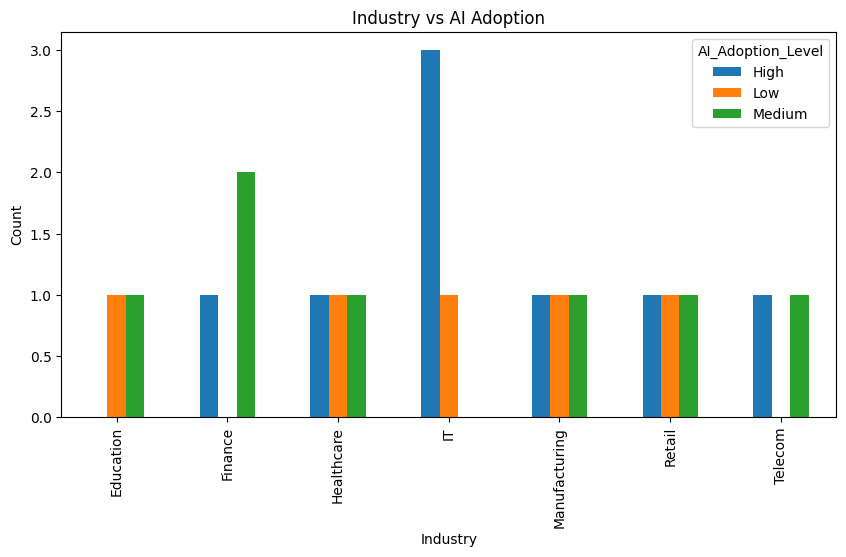

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

industry_adoption = pd.crosstab(
    df['Industry'],
    df['AI_Adoption_Level']
)

industry_adoption.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Industry vs AI Adoption')
plt.ylabel('Count')
plt.show()

Company Size vs Adoption (Bar Chart)

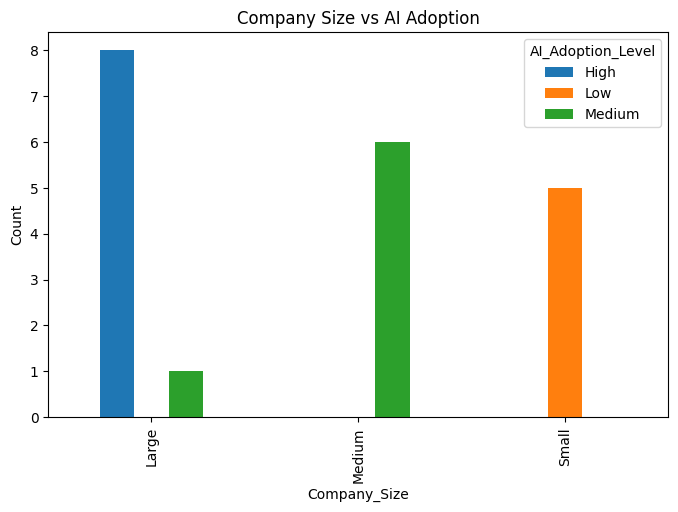

In [ ]:
company_adoption = pd.crosstab(
    df['Company_Size'],
    df['AI_Adoption_Level']
)

company_adoption.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Company Size vs AI Adoption')
plt.ylabel('Count')
plt.show()

AI Projects vs Employee Satisfaction(Bar Chart)

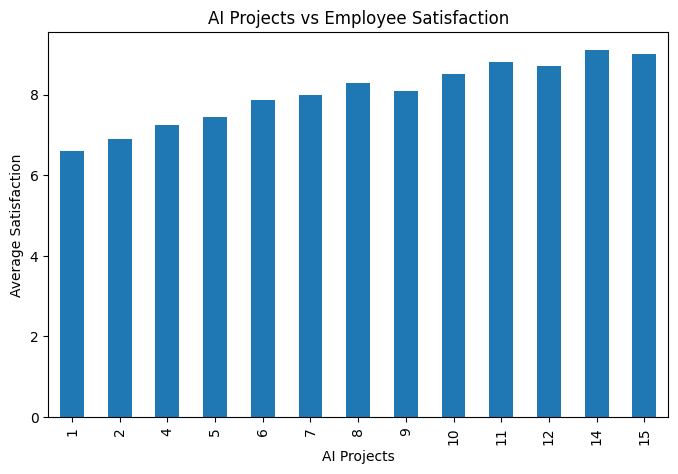

In [ ]:
project_satisfaction = df.groupby(
    'AI_Projects'
)['Employee_Satisfaction'].mean()

project_satisfaction.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('AI Projects vs Employee Satisfaction')
plt.ylabel('Average Satisfaction')
plt.xlabel('AI Projects')
plt.show()

create a synthetic adoption year

In [ ]:
import numpy as np

df['Adoption_Year'] = np.random.choice(
    [2020, 2021, 2022, 2023, 2024],
    size=len(df)
)

In [ ]:
print(df.columns)

Index(['Company_ID', 'Industry', 'Company_Size', 'Employees',
       'AI_Investment_USD', 'AI_Projects', 'Training_Hours',
       'AI_Adoption_Level', 'Productivity_Improvement', 'ROI_Percentage',
       'Employee_Satisfaction', 'Category', 'Adoption_Year'],
      dtype='object')


Adoption Year vs Growth (Line Chart)

Adoption_Year
2020    16.000000
2021    20.200000
2022    23.000000
2023    14.000000
2024    15.333333
Name: Productivity_Improvement, dtype: float64


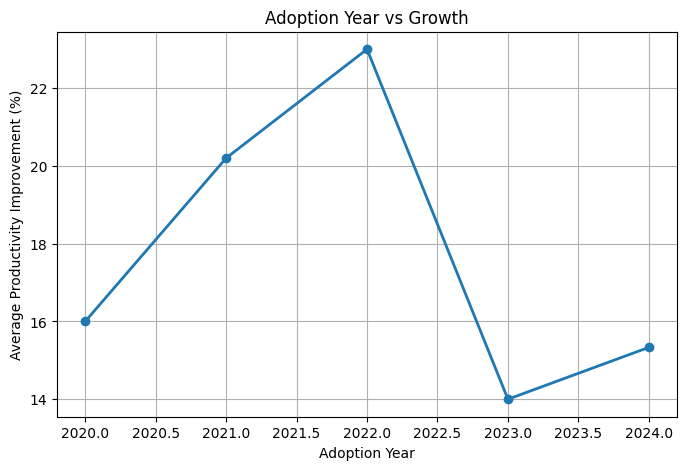

In [ ]:
import matplotlib.pyplot as plt

year_growth = df.groupby(
    'Adoption_Year'
)['Productivity_Improvement'].mean()

print(year_growth)

plt.figure(figsize=(8,5))

plt.plot(
    year_growth.index,
    year_growth.values,
    marker='o',
    linewidth=2
)

plt.title('Adoption Year vs Growth')
plt.xlabel('Adoption Year')
plt.ylabel('Average Productivity Improvement (%)')

plt.grid(True)
plt.show()

Employee Count vs AI Usage(Scatter Plot)





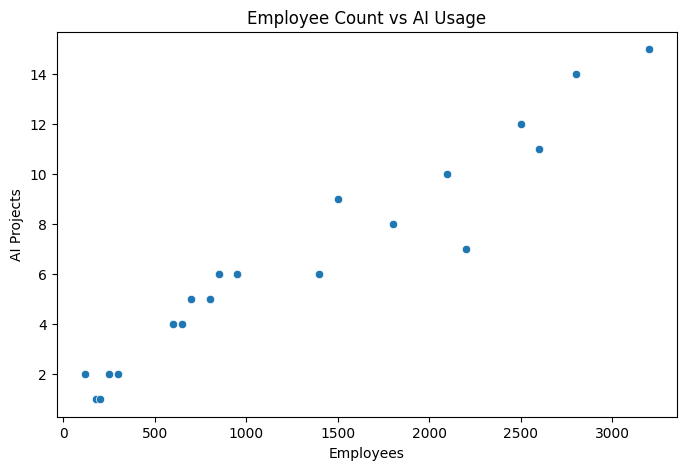

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Employees',
    y='AI_Projects'
)

plt.title('Employee Count vs AI Usage')
plt.xlabel('Employees')
plt.ylabel('AI Projects')

plt.show()

Phase 4: Correlation Analysis

In [ ]:
corr = df[
[
'Employees',
'AI_Investment_USD',
'AI_Projects',
'Training_Hours',
'Productivity_Improvement',
'ROI_Percentage',
'Employee_Satisfaction'
]
].corr()

corr

,Employees,AI_Investment_USD,AI_Projects,Training_Hours,Productivity_Improvement,ROI_Percentage,Employee_Satisfaction
Employees,1.000000,0.968686,0.964516,0.947250,0.961080,0.966725,0.957847
AI_Investment_USD,0.968686,1.000000,0.987325,0.948853,0.966134,0.966552,0.955581
AI_Projects,0.964516,0.987325,1.000000,0.975294,0.985871,0.984957,0.979021
Training_Hours,0.947250,0.948853,0.975294,1.000000,0.992468,0.991092,0.993185
Productivity_Improvement,0.961080,0.966134,0.985871,0.992468,1.000000,0.999293,0.992921
ROI_Percentage,0.966725,0.966552,0.984957,0.991092,0.999293,1.000000,0.991626
Employee_Satisfaction,0.957847,0.955581,0.979021,0.993185,0.992921,0.991626,1.000000


Adoption vs Productivity

In [ ]:
adoption_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

df['Adoption_Score'] = df['AI_Adoption_Level'].map(adoption_map)

correlation = df['Adoption_Score'].corr(
    df['Productivity_Improvement']
)

print("Correlation:", correlation)

Correlation: 0.9369890618104177


Tool Usage vs Satisfaction

In [ ]:
correlation = df['AI_Projects'].corr(
    df['Employee_Satisfaction']
)

print("Correlation:", correlation)

Correlation: 0.9790205466797792


Employee Count vs Adoption

In [ ]:
correlation = df['Employees'].corr(
    df['Adoption_Score']
)

print("Correlation:", correlation)

Correlation: 0.9043114718841136


AI Investment vs ROI (Savings Proxy)

In [ ]:
correlation = df['AI_Investment_USD'].corr(
    df['ROI_Percentage']
)

print("Correlation:", correlation)

Correlation: 0.9665517393310353


Heatmap

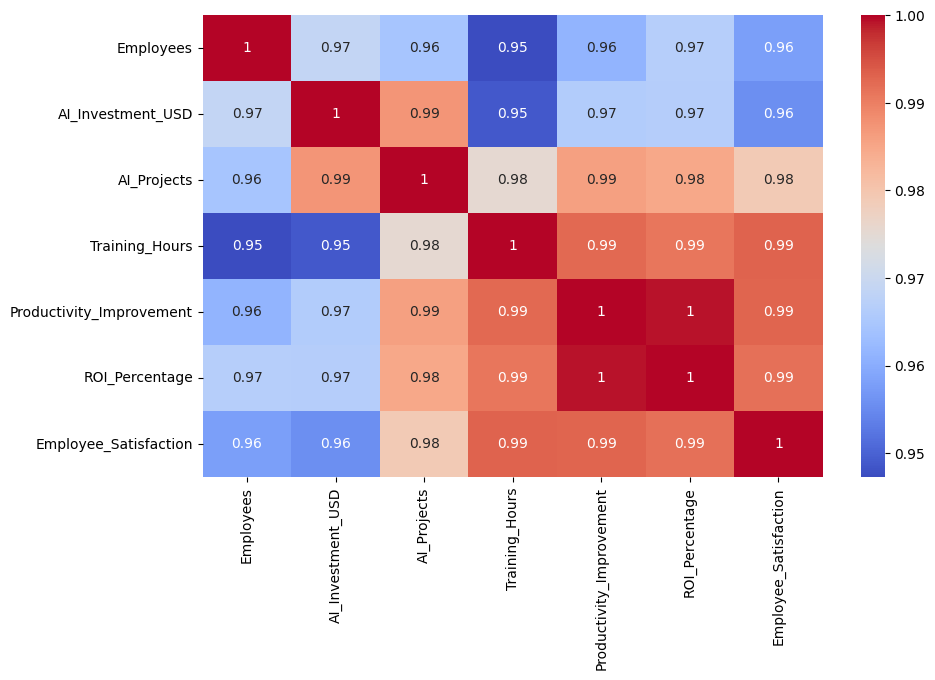

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

Phase 5: Hypothesis Testing

In [ ]:
from scipy.stats import f_oneway

small = df[
df["Company_Size"]=="Small"
]["Productivity_Improvement"]

medium = df[
df["Company_Size"]=="Medium"
]["Productivity_Improvement"]

large = df[
df["Company_Size"]=="Large"
]["Productivity_Improvement"]

f,p = f_oneway(
small,
medium,
large
)

print("P Value =",p)

P Value = 2.1367252122749364e-07


Decision

In [ ]:
if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


Phase 6: Organization Segmentation

In [ ]:
def segment(row):

    if row["ROI_Percentage"] >= 30:
        return "High ROI"

    elif row["AI_Adoption_Level"] == "High":
        return "AI Leader"

    elif row["Employee_Satisfaction"] >= 8:
        return "High Satisfaction"

    else:
        return "Developing"

df["Category"] = df.apply(
    segment,
    axis=1
)

df["Category"].value_counts()

,count
Category,
Developing,12
High ROI,6
AI Leader,2


Phase 7: Business Insights

In [ ]:
print(
"Average Productivity:",
df["Productivity_Improvement"].mean()
)

print(
"Average ROI:",
df["ROI_Percentage"].mean()
)

print(
"Average Satisfaction:",
df["Employee_Satisfaction"].mean()
)

Average Productivity: 18.15
Average ROI: 22.8
Average Satisfaction: 7.7700000000000005
